# BELT Basic Example

In [1]:
from belt.run import BELT
import os
from belt.particles import BELTParticleData

# Setup

Instantiate the object on a value init file. This will configure a working directory that stages all input and output files.

In [2]:
!which xbelt

~/miniconda3/envs/lume-eblt-dev/bin/xbelt


In [3]:
test = BELT(
    input="lcls-ii-backtracking-example/belt.in",
    workdir=os.environ.get("SCRATCH"),
    # command="/sdf/group/ad/sw/beta/bin/xbelt",
)

In [4]:
test.initial_particles = BELTParticleData.from_BELT_outputfile(
    "./lcls-ii-backtracking-example/fort.201"
)

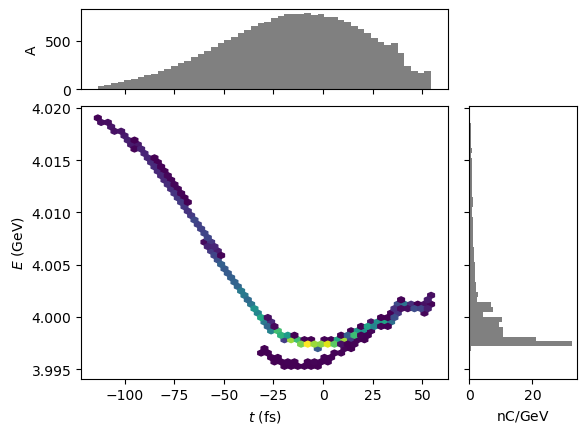

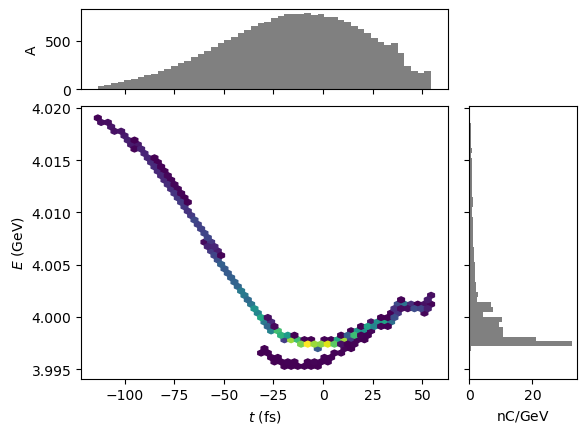

In [5]:
test.initial_particles.plot(xkey="t", ykey="energy")

Here is what the parsed input looks like

In [7]:
test.initial_particles.z

array([-9.59457592e-06,  2.05564147e-06, -2.11990745e-07, ...,
       -9.75580564e-06, -1.18030938e-05,  2.38465824e-06])

In [6]:
test.input.parameters

Parameters(np=200000, nz=128, zmin=-0.002981592, zmax=0.002211398, flagfwd=1, flagdist=100, Iavg=0.13, Ek=100000000.0, mass=511005.0, charge=-1.0, freq=1300000000.0)

In [9]:
test.input.parameters.flagfwd = -1
test.input.parameters.zmin = min(test.initial_particles.z)
test.input.parameters.zmax = max(test.initial_particles.z)

In [10]:
test.input.lattice_lines

[WriteBeam(iwrite=102, sample=1, name='DumpLH'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=1.0, name='Wake1'),
 RFCavity(length=16.6, beam_radius=0.0003, gradient=13698795.0, frequency=1300000000.0, phase_deg=-28.5, name='L1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=-1.0, name='Wake1off'),
 DriftTube(length=8.5305163742, beam_radius=0.0003, name='D2'),
 WriteBeam(iwrite=104, sample=1, name='DumpL1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=1.0, name='Wake2'),
 RFCavity(length=5.53, beam_radius=0.0003, gradient=9168000.0, frequency=3900000000.0, phase_deg=-170.0, name='HL'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=-1.0, name='Wake2off'),
 WriteBeam(iwrite=106, sample=1, name='DumpHL'),
 DriftTube(length=12.518616788, beam_radius=0.0003, name='D3'),
 DriftTube(length=7.256313209, beam_radius=0.0003, name='D4'),
 ChangeEnergy(energy_increment=5462800.0, na

The input format that belt will see

In [11]:
test.write_input()
print(test.path)
!cat {test.path}/belt.in

Updating Ek in the header to 4011256458.28017 eV
/sdf/scratch/users/j/jytang/tmp0gbs6bax
! np nz zmin zmax flagfwd flagdist
200000 128 -3.40184621402e-05 1.6310587366e-05 -1 100 /
! a0 a1 a2 a3 a4 a5 a6 a7 a8 a9
0 0 0 /
! b0 b1 b2 b3 b4 b5 b6 b7 b8 b9
1 0 0 /
! Iavg Ek mass charge freq
0.0975 4011256458.28017 511005 7.5e-11 1300000000 /
! length Bnseg Bmpstp WriteBeam name
0 1 102 -2 1 / !name: DumpLH
! length Bnseg Bmpstp Wakefield multiplier wake_function_file_id switch name
0 1 1 -41 1 41 1 / !name: Wake1
! length Bnseg Bmpstp RFCavity beam_radius gradient frequency phase_deg name
16.6 1 1 103 0.0003 13698795 1300000000 -28.5 / !name: L1
! length Bnseg Bmpstp Wakefield multiplier wake_function_file_id switch name
0 1 1 -41 1 41 -1 / !name: Wake1off
! length Bnseg Bmpstp Drift name
8.5305163742 1 1 0 0.0003 / !name: D2
! length Bnseg Bmpstp WriteBeam name
0 1 104 -2 1 / !name: DumpL1
! length Bnseg Bmpstp Wakefield multiplier wake_function_file_id switch name
0 1 1 -41 1 42 1 / !name

# Run

In [12]:
output = test.run()

Updating Ek in the header to 4011256458.28017 eV


In [13]:
test.output.run

RunInfo(error=False, error_reason='', run_script='/sdf/home/j/jytang/miniconda3/envs/lume-eblt-dev/bin/xbelt', run_time=16.029207567684352)

# Output

<!-- lume-genesis detected Jupyter and will use HTML for rendering. -->

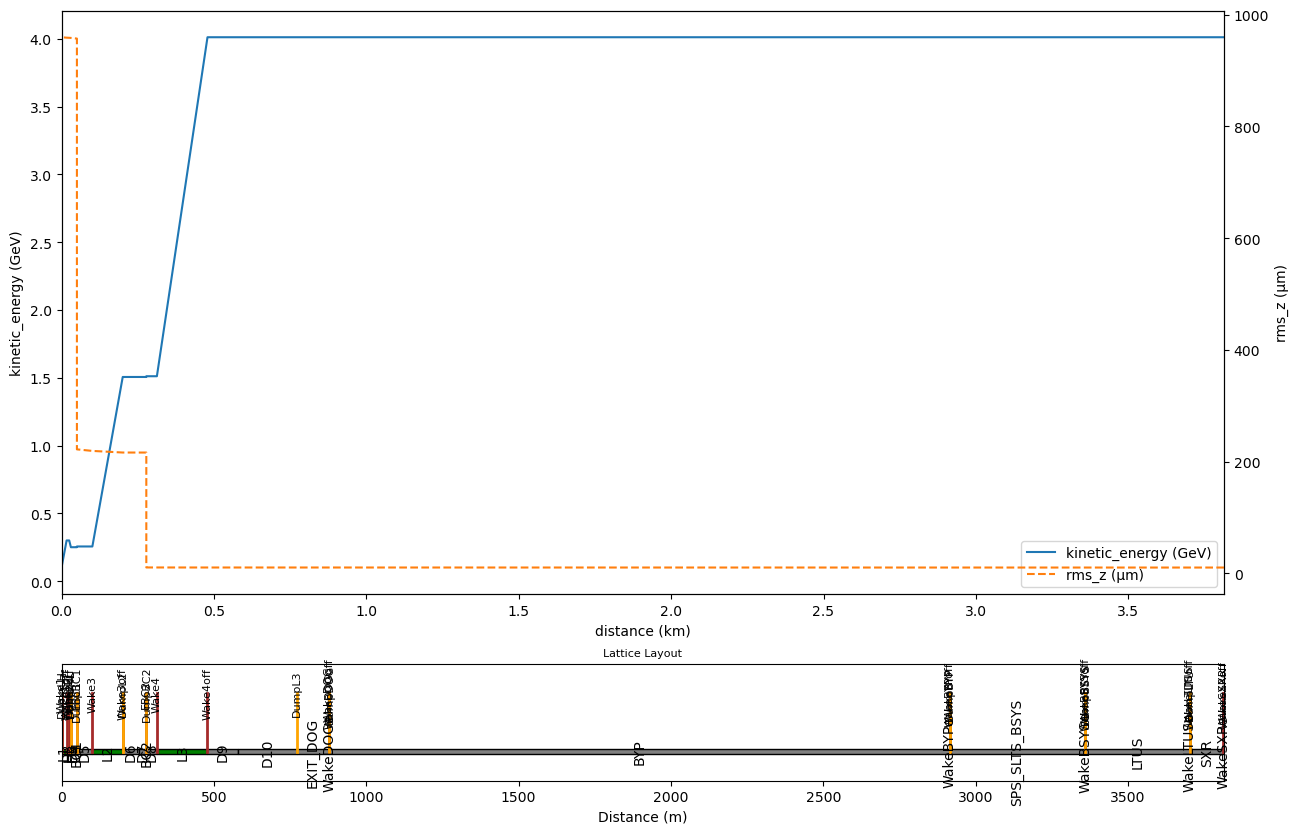

In [14]:
test.plot()

In [15]:
particles = test.output.particle_distributions
print(particles.keys())

dict_keys([115, 109, 103, 101, 117, 113, 201, 121, 111, 107, 105, 119, 123])


initial particle distribution

In [16]:
import numpy as np

np.sum(particles[201].weight)

np.float64(7.5e-11)

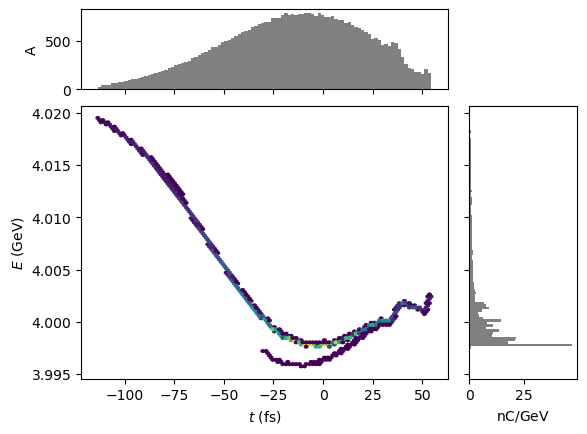

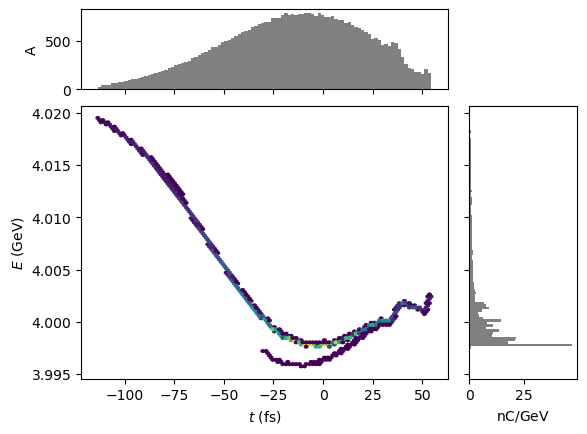

In [17]:
test.output.plot_distribution(file_id=101, xkey="t", ykey="energy", bins=100)

LPS after BC1

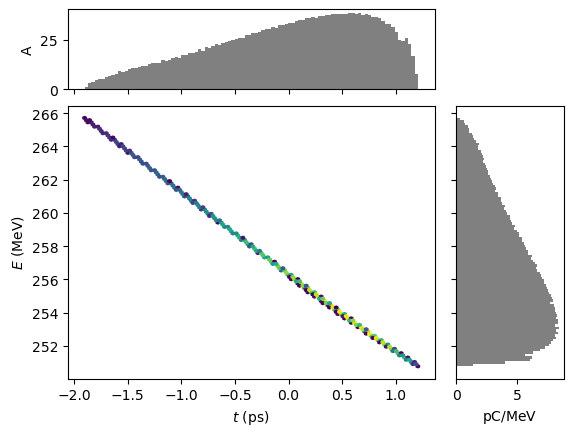

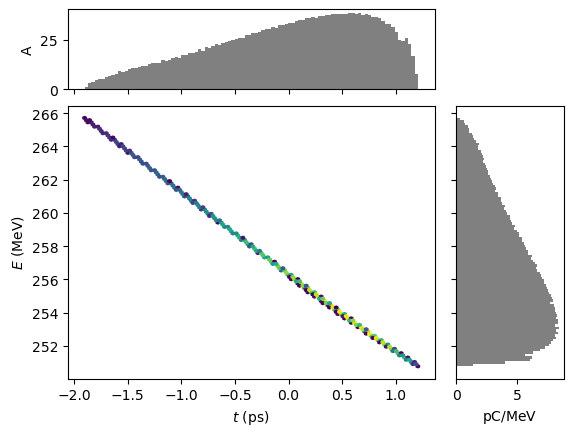

In [18]:
test.output.plot_distribution(file_id=109, xkey="t", ykey="energy", bins=100)

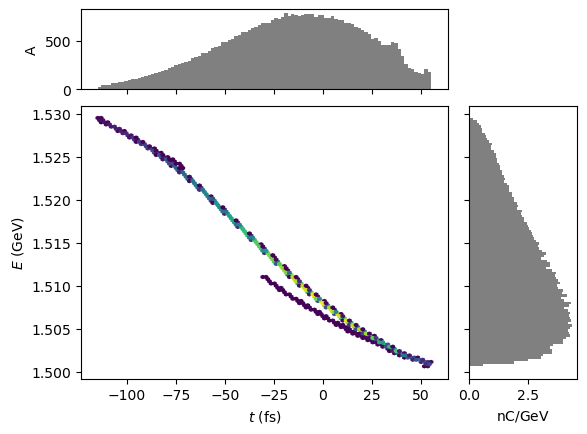

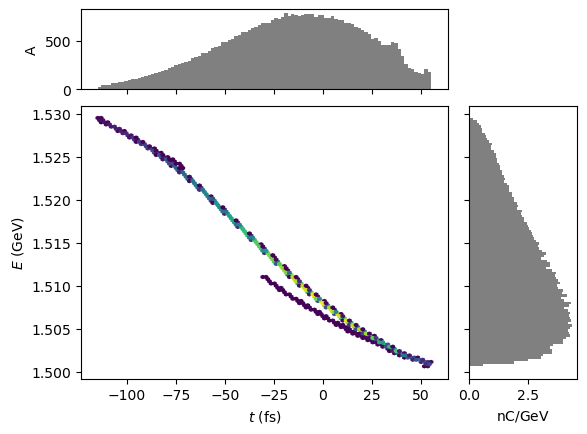

In [19]:
# After BC2
test.output.plot_distribution(file_id=113, xkey="t", ykey="energy", bins=100)

Final LPS

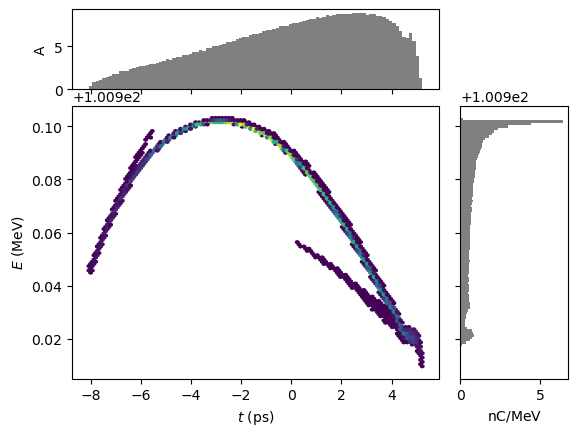

In [20]:
fig = test.output.plot_distribution(file_id=201, xkey="t", ykey="energy", bins=100)

# Archiving

In [ ]:
test.archive("./archivefile.h5")

In [6]:
test.load_archive("./archivefile.h5")

In [16]:
test.output.particle_distributions.keys()

dict_keys([201, 119, 115, 123, 105, 103, 113, 101, 121, 117, 109, 107, 111])